# PyTorch Basics - Tensors and Autograd

In [7]:
# Import essential libraries
import torch
import matplotlib.pyplot as plt

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.5.1
CUDA available: True
CUDA device: Tesla V100-PCIE-32GB


## 1. Tensor Creation and Basic Operations

In [8]:
# From lists
x = torch.tensor([1, 2, 3, 4, 5])
print(f"From list: {x}")

# Random tensors
y = torch.randn(3, 4)
z = torch.rand(3, 4)   

# Special tensors
zeros = torch.zeros(2, 3)
ones = torch.ones(2, 3)

print(f"Zeros:\n{zeros}")
print(f"Ones:\n{ones}")

From list: tensor([1, 2, 3, 4, 5])
Zeros:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
Ones:
tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [9]:
# Tensor operations
print("=== Basic Operations ===")

a = torch.randn(3, 4)
b = torch.randn(3, 4)

# Element-wise operations
c = a + b
d = torch.add(a, b)
e = a * b  # Element-wise multiplication
e = torch.mul(a, b)

print(f"Shape of a: {a.shape}")
print(f"Addition result shape: {c.shape}")
print(f"Are c and d equal? {torch.equal(c, d)}")

# Matrix multiplication
f = torch.randn(3, 4)
g = torch.randn(4, 5)
h = torch.mm(f, g)

print(f"Matrix multiplication result shape: {h.shape}")

=== Basic Operations ===
Shape of a: torch.Size([3, 4])
Addition result shape: torch.Size([3, 4])
Are c and d equal? True
Matrix multiplication result shape: torch.Size([3, 5])


## 2. Device Management (CPU/GPU)

In [10]:
# Device management
print("=== Device Management ===")

# Check available device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create tensor on specific device
x_cpu = torch.randn(3, 4)
x_device = torch.randn(3, 4, device=device)

print(f"x_cpu device: {x_cpu.device}")
print(f"x_device device: {x_device.device}")

# Move tensors between devices
x_moved = x_cpu.to("cuda:2")
print(f"x_moved device: {x_moved.device}")

try:
    result = x_cpu + x_device
except RuntimeError:
    print("Cannot do operations on tensors on different devices")


=== Device Management ===
Using device: cuda
x_cpu device: cpu
x_device device: cuda:0
x_moved device: cuda:2
Cannot do operations on tensors on different devices


## 3. Automatic Differentiation (Autograd)

In [11]:
# Autograd basics
print("=== Automatic Differentiation ===")

# Create tensor that requires gradient
x = torch.tensor([2.0], requires_grad=True)

# Define a function: y = x^2 + 3x + 1
y = x**2 + 3*x + 2*x+  1
print(f"y: {y}")
print(f"y.requires_grad: {y.requires_grad}")

# Compute gradients
y.backward()  # dy/dx = 2x + 3
print(f"Gradient dy/dx at x=2: {x.grad}")
print(f"Expected: 2*2 + 3 = {2*2 + 3}")

=== Automatic Differentiation ===
y: tensor([15.], grad_fn=<AddBackward0>)
y.requires_grad: True
Gradient dy/dx at x=2: tensor([9.])
Expected: 2*2 + 3 = 7


In [12]:
# More complex example with vectors
print("=== Vector Gradients ===")

# Create input vector
x = torch.randn(3, requires_grad=True)
print(f"Input x: {x}")

# Simple linear transformation: y = Wx + b
W = torch.randn(2, 3, requires_grad=True)
b = torch.randn(2, requires_grad=True)

y = W @ x + b
print(f"Output y: {y}")

# Compute scalar loss (sum of squares)
loss = (y**2).sum()
print(f"Loss: {loss}")

# Backward pass
loss.backward()

print(f"Gradient w.r.t. x: {x.grad}")
print(f"Gradient w.r.t. W: {W.grad}")
print(f"Gradient w.r.t. b: {b.grad}")

=== Vector Gradients ===
Input x: tensor([ 1.2012, -0.4493,  0.8733], requires_grad=True)
Output y: tensor([-1.6671, -1.1466], grad_fn=<AddBackward0>)
Loss: 4.0940470695495605
Gradient w.r.t. x: tensor([4.5439, 0.3144, 0.9519])
Gradient w.r.t. W: tensor([[-4.0049,  1.4979, -2.9119],
        [-2.7546,  1.0303, -2.0028]])
Gradient w.r.t. b: tensor([-3.3342, -2.2933])


## 4. Tensor Reshaping and Indexing

In [13]:
# Tensor reshaping - crucial for neural networks
print("=== Tensor Reshaping ===")

# Create a tensor representing a batch of images
# Shape: (batch_size, channels, height, width)
images = torch.randn(32, 3, 28, 28)  # 32 RGB images of 28x28
print(f"Original shape: {images.shape}")

# Flatten for fully connected layer
flattened = images.view(32, -1)
print(f"Flattened shape: {flattened.shape}")
print(f"Expected: 32 x (3*28*28) = 32 x {3*28*28}")

=== Tensor Reshaping ===
Original shape: torch.Size([32, 3, 28, 28])
Flattened shape: torch.Size([32, 2352])
Expected: 32 x (3*28*28) = 32 x 2352


In [14]:
# Indexing and slicing
print("=== Indexing and Slicing ===")

x = torch.randn(4, 5)
print(f"Original tensor shape: {x.shape}")

# Basic indexing
print(f"First row: {x[0]}")
print(f"First column: {x[:, 0]}")
print(f"Element at (1,2): {x[1, 2]}")

# Advanced indexing
indices = torch.tensor([0, 2])
selected_rows = x[indices]
print(f"Selected rows (0,2): {selected_rows.shape}")

# Boolean indexing
mask = x > 0
positive_values = x[mask]
print(f"Number of positive values: {positive_values.shape[0]}")

=== Indexing and Slicing ===
Original tensor shape: torch.Size([4, 5])
First row: tensor([ 0.0948, -0.3432, -1.3576, -0.0205,  0.3211])
First column: tensor([ 0.0948,  2.6601,  1.8750, -0.8623])
Element at (1,2): -0.8804865479469299
Selected rows (0,2): torch.Size([2, 5])
Number of positive values: 13


## 5. Common Functions for Deep Learning

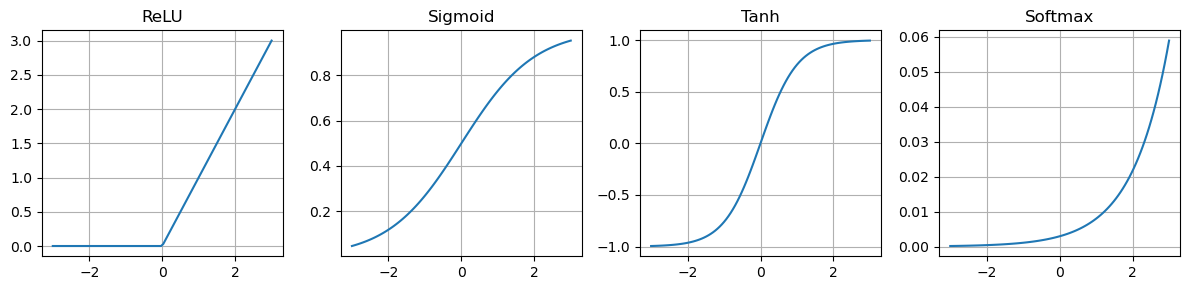

In [15]:
# here we see some applications of the non-linear activation functions. Whenever you actually implement a network you should use those.
x = torch.linspace(-3, 3, 100)

# Common activation functions
relu = torch.relu(x)
sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
softmax = torch.softmax(x.unsqueeze(0), dim=1).squeeze()

# Plot them
plt.figure(figsize=(12, 3))

plt.subplot(1, 4, 1)
plt.plot(x.numpy(), relu.numpy())
plt.title('ReLU')
plt.grid(True)

plt.subplot(1, 4, 2)
plt.plot(x.numpy(), sigmoid.numpy())
plt.title('Sigmoid')
plt.grid(True)

plt.subplot(1, 4, 3)
plt.plot(x.numpy(), tanh.numpy())
plt.title('Tanh')
plt.grid(True)

plt.subplot(1, 4, 4)
plt.plot(x.numpy(), softmax.numpy())
plt.title('Softmax')
plt.grid(True)

plt.tight_layout()
plt.show()

## 6. Quick Exercise

Try to implement a simple linear regression manually using PyTorch tensors and autograd!

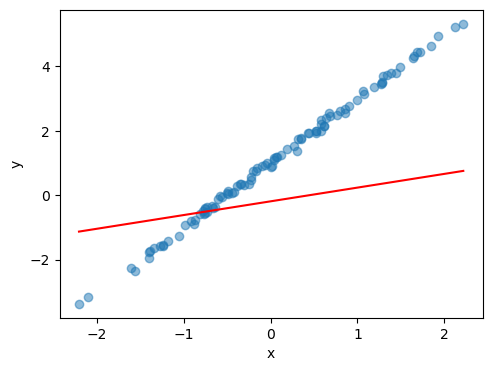

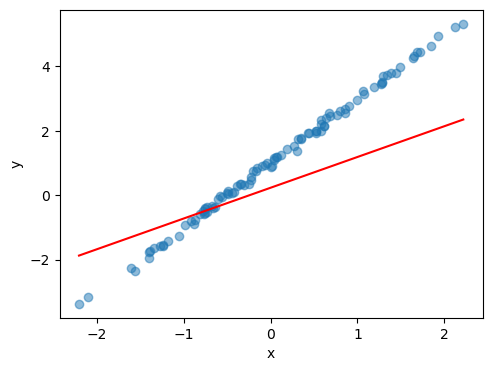

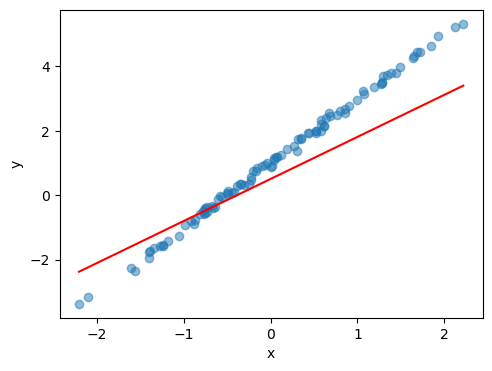

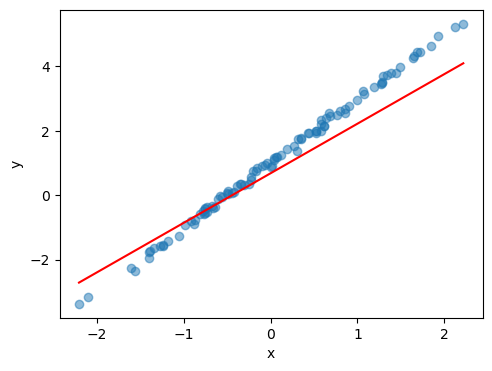

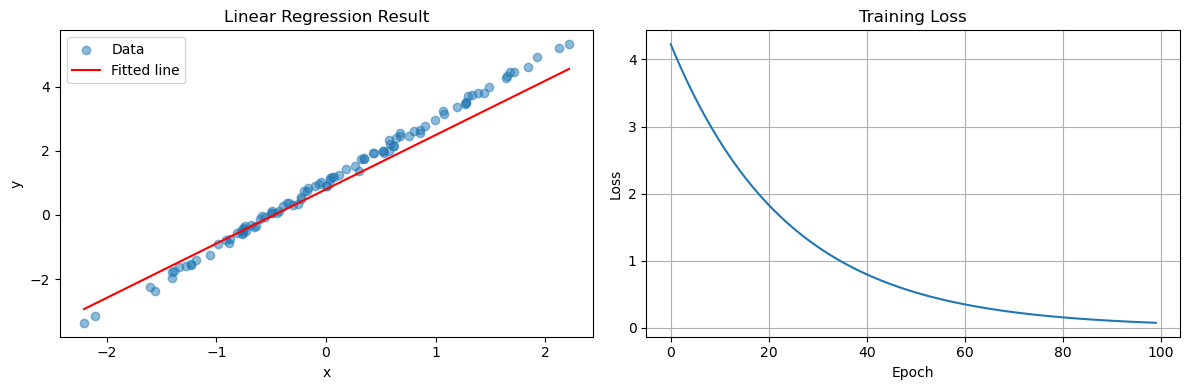


Final parameters that are used for our very simple linear regression: w=1.792, b=0.868
True parameters: w=2.000, b=1.000


In [16]:
import time
# Generate synthetic data: y = 2x + 1 + noise between 0,1
# setting the seed is super important since it guarntees that the random values for the x_data are always the same
torch.manual_seed(42)
n_samples = 100
x_data = torch.randn(n_samples, 1)
y_data = 2 * x_data + 1 + 0.1 * torch.randn(n_samples, 1)

# Initialize parameters
w = torch.randn(1, 1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

# Training parameters
learning_rate = 0.01
n_epochs = 100

losses = []

for epoch in range(n_epochs):

    # Forward pass
    y_pred = x_data @ w + b
    
    # Compute loss (MSE), note that we take the mean here over the whole dataset to calculate the update that we want to take.
    loss = ((y_pred - y_data) ** 2).mean()

    # saving the loss so we can plot it for later
    losses.append(loss.item())
    
    # here we tell the loss to compute the gradients that we need to make the update
    loss.backward()
    
    # Update parameters, with deactivate gradients. Else this operation would be added to the gradients as well, even though we set them to zero afterwards it is good practice!!
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
        
        # Zero gradients, very important!!!
        w.grad.zero_()
        b.grad.zero_()
    if epoch % 20 == 0:
        plt.figure(figsize=(12, 4))
        time.sleep(1)
        plt.subplot(1, 2, 1)
        plt.scatter(x_data.numpy(), y_data.numpy(), alpha=0.5, label='Data')
        x_line = torch.linspace(x_data.min(), x_data.max(), 100).unsqueeze(1)
        y_line = x_line @ w + b
        plt.plot(x_line.detach().numpy(), y_line.detach().numpy(), 'r-', label='Fitted line')
        plt.xlabel('x')
        plt.ylabel('y')
        
plt.legend()
plt.title('Linear Regression Result')
plt.subplot(1, 2, 2)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.tight_layout()
plt.show()
    
print(f"\nFinal parameters that are used for our very simple linear regression: w={w.item():.3f}, b={b.item():.3f}")
print(f"True parameters: w=2.000, b=1.000")
